In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import null_space

# Exercise 11-1
- Residuals are orthogonal to the predicted data
- Make a scatterplot of the predicted data by the errors
- Compute the dot product and the correlation coefficient between the residuals and the model predicted data
- In theory both should be exactly zero

In [23]:
numcourses = [13,4,12,3,14,13,12,9,11,7,13,11,9,2,5,7,10,0,9,7]
happiness  = [70,25,54,21,80,68,84,62,57,40,60,64,45,38,51,52,58,21,75,70]

In [24]:
# design matrix as a column vector
X = np.hstack((np.ones((20,1)),np.array(numcourses,ndmin=2).T))

# fit the model using the left-inverse
X_leftinv = np.linalg.inv(X.T@X) @ X.T

In [25]:
# solve for the coefficients
beta = X_leftinv @ happiness
beta

array([23.13033815,  3.69820606])

In [26]:
pred_happiness = X @ beta

In [27]:
# Find residuals
res = happiness - pred_happiness
print(res @ pred_happiness)
coeff = np.corrcoef(res, pred_happiness)[0,1]
print(coeff)


-6.133404895081185e-11
-9.240510456164651e-17


Text(0.5, 1.0, 'Coefficient: -0.00000000000000009241')

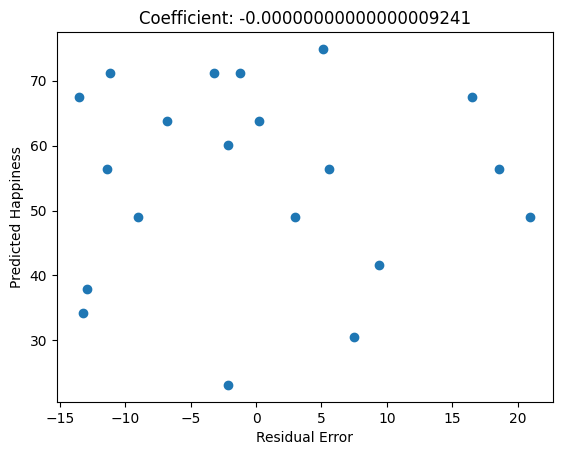

In [28]:
plt.scatter(x=res, y=pred_happiness)
plt.xlabel("Residual Error")
plt.ylabel("Predicted Happiness")
plt.title(f"Coefficient: {coeff:.20f}")

In [29]:
# should basically be zero (which it is)
res @ pred_happiness

np.float64(-6.133404895081185e-11)

# Exercise 11-2
- the model-predicted happiness is merely one way of linearly combining the columns of the design matrix
- the residuals vector isn't only orthogonal to that one linear weighted combination
- it is orthogonal to the entire subspace spanned by the design matrix

In [30]:
# compute the null space (via scipy.linalg)
nullspace = null_space(X.T)


# augment the residuals
nullspaceAugment = np.hstack( (nullspace,res.reshape(-1,1)) )


# print their ranks
print(f'dim(  N(X)    ) = {np.linalg.matrix_rank(nullspace)}')
print(f'dim( [N(X)|r] ) = {np.linalg.matrix_rank(nullspaceAugment)}')

dim(  N(X)    ) = 18
dim( [N(X)|r] ) = 18


# Exercise 11-3
